In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [42]:
from google.colab import files

uploaded = files.upload()

Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain (2).csv


In [43]:
df = pd.read_csv("DailyDelhiClimateTrain.csv")

In [44]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [46]:
df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [47]:
df['Day_Number'] = np.arange(len(df))

In [48]:
X = df[['Day_Number']]
y = df['meantemp']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.2,
                  random_state=42
                  )


In [50]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [51]:
predictions = model.predict(X_test)

In [52]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 53.69697615811494


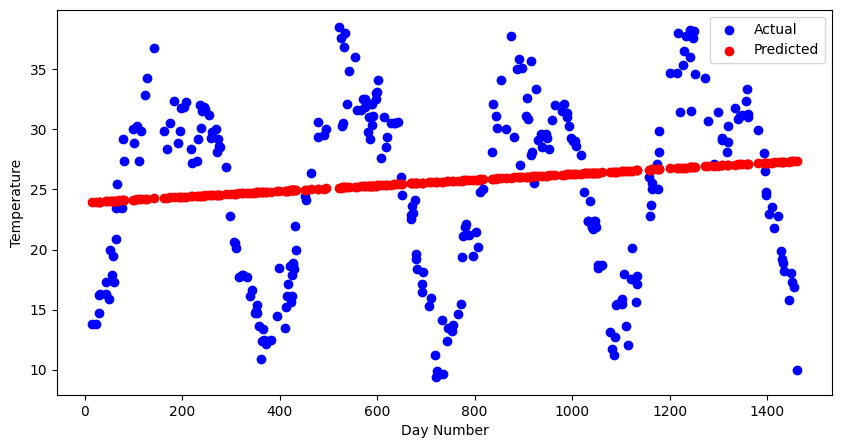

In [53]:
plt.figure(figsize=(10,5))

plt.scatter(X_test, y_test, color='blue', label='Actual')

plt.scatter(X_test, predictions, color='red', label='Predicted')

plt.xlabel("Day Number")
plt.ylabel("Temperature")

plt.legend()

plt.show()

In [54]:
future_days = np.arange(len(df), len(df)+30).reshape(-1,1)

future_temp = model.predict(future_days)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [55]:
future_df = pd.DataFrame({
      "Future Day": future_days.flatten(),
          "Predicted Temperature": future_temp
          })

future_df


,Future Day,Predicted Temperature
0,1462,27.362183
1,1463,27.364536
2,1464,27.366889
3,1465,27.369243
4,1466,27.371596
5,1467,27.373949
6,1468,27.376303
7,1469,27.378656
8,1470,27.381009
9,1471,27.383363


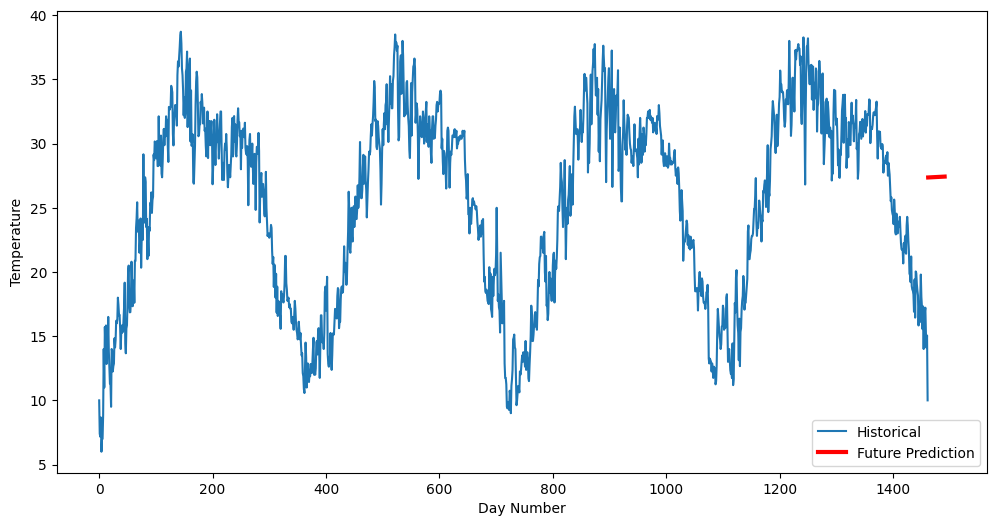

In [56]:
plt.figure(figsize=(12,6))

plt.plot(df['Day_Number'], df['meantemp'], label='Historical')

plt.plot(
    future_days,
    future_temp,
    color='red',
    linewidth=3,
    label='Future Prediction'
  )

plt.xlabel("Day Number")
plt.ylabel("Temperature")

plt.legend()

plt.show()